![4 bar diagram](74bbcdf260763.jpeg)

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


In [35]:
def trajectory(b, d, e, x_1, y_1, x_2, y_2, theta, configuration='open'):
    theta = np.asarray(theta, dtype=float)

    # Position of (s,t)
    s = x_2 + b * np.cos(theta)
    t = y_2 + b * np.sin(theta)

    # Distance from (x1, y1) to (s, t)
    c = np.sqrt((s - x_1) ** 2 + (t - y_1) ** 2)

    # Only keep linkage states that can actually close
    valid = (np.abs(e - d) <= c) & (c <= e + d)
    if not np.any(valid):
        raise ValueError('No valid theta values for this linkage geometry.')

    theta = theta[valid]
    s = s[valid]
    t = t[valid]
    c = c[valid]

    angle_c = np.arctan2(t - y_1, s - x_1)
    cos_omega = (c ** 2 + e ** 2 - d ** 2) / (2 * c * e)
    omega = np.arccos(cos_omega)

    if configuration == 'open':
        angle_e = angle_c + omega
    else:
        angle_e = angle_c - omega

    m = x_1 + e * np.cos(angle_e)
    n = y_1 + e * np.sin(angle_e)

    return theta, s, t, m, n, valid


Skipped 4 unreachable theta value(s).
Valid theta range used for plotting: 0.314 to 1.414
Verification: max deviation from d = 2.0 is 7.55e-15
Distance check PASSED!


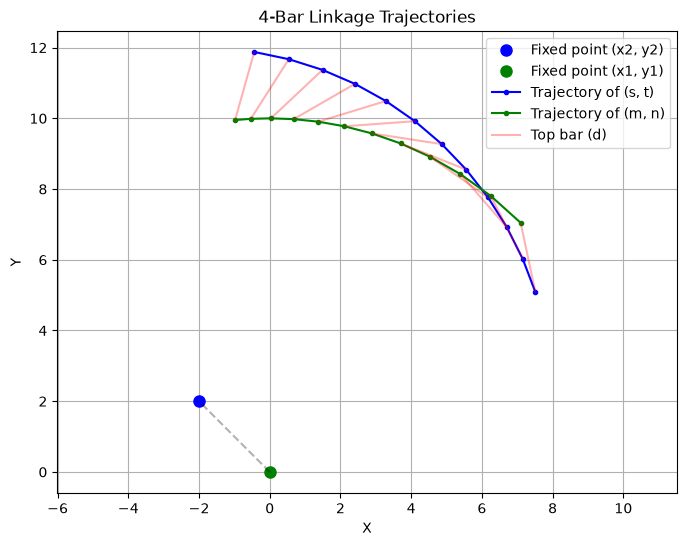

In [36]:
# INPUT HERE
b, d, e = 10.0, 2.0, 10.0
x_1, y_1 = 0.0, 0.0
x_2, y_2 = -2.0, 2.0

# theta array
theta = np.arange(3.14 * 0.1, 3.14 * 0.6, 0.1)

theta_valid, s, t, m, n, valid = trajectory(b, d, e, x_1, y_1, x_2, y_2, theta)

if np.any(~valid):
    print(f'Skipped {np.count_nonzero(~valid)} unreachable theta value(s).')
    print(f'Valid theta range used for plotting: {theta_valid[0]:.3f} to {theta_valid[-1]:.3f}')

# Verify distance between (s,t) and (m,n) is exactly d
calculated_d = np.sqrt((s - m) ** 2 + (t - n) ** 2)
max_error = np.max(np.abs(calculated_d - d))
print(f'Verification: max deviation from d = {d} is {max_error:.2e}')
print('Distance check PASSED!' if np.allclose(calculated_d, d) else 'Distance check FAILED!')

plt.figure(figsize=(8, 6))
plt.plot(x_2, y_2, 'bo', markersize=8, label='Fixed point (x2, y2)')
plt.plot(x_1, y_1, 'go', markersize=8, label='Fixed point (x1, y1)')
plt.plot([x_1, x_2], [y_1, y_2], 'k--', alpha=0.3)

plt.plot(s, t, 'b.-', label='Trajectory of (s, t)')
plt.plot(m, n, 'g.-', label='Trajectory of (m, n)')

for i in range(len(s)):
    plt.plot([s[i], m[i]], [t[i], n[i]], 'r-', alpha=0.3)

plt.plot([], [], 'r-', alpha=0.3, label='Top bar (d)')
plt.title('4-Bar Linkage Trajectories')
plt.xlabel('X')
plt.ylabel('Y')
plt.axis('equal')
plt.legend()
plt.grid(True)
plt.show()
